<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Optimization (4pt)

Test training with Adam, SGD or RMSProp optimizers. Run at least 4 different configurations (different steps, different alpha, beta, etc). For this task, it is advisable to use the graphs in the pdf.

Choose one method and additionally test three other minibatch sizes for it.

In [1]:
!mkdir -p baseline
# I might make the repo private in the future so the files from /baseline directory from the zip file might have to be used
!wget -O baseline/baseline_model.pth https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
!wget -O baseline/baseline_results.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json


--2025-11-02 09:49:35--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 419703 (410K) [application/octet-stream]
Saving to: ‘baseline/baseline_model.pth’

baseline/baseline_m 100%[===================>] 409.87K  --.-KB/s    in 0.03s   

2025-11-02 09:49:35 (15.5 MB/s) - ‘baseline/baseline_model.pth’ saved [419703/419703]

--2025-11-02 09:49:35--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443.

In [2]:
import json

with open('baseline/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:04<00:00, 41.9MB/s]


torch.Size([1, 3, 32, 32])


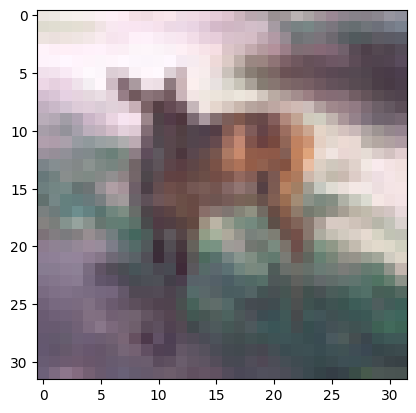

tensor([4])
deer
torch.Size([1, 3, 32, 32])


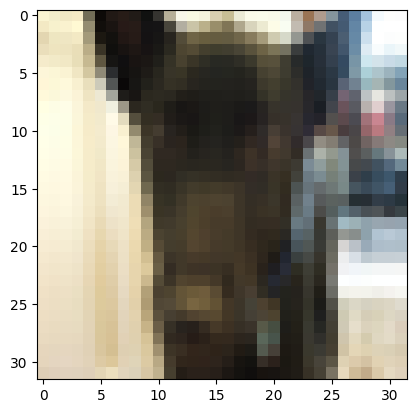

tensor([5])
dog
torch.Size([1, 3, 32, 32])


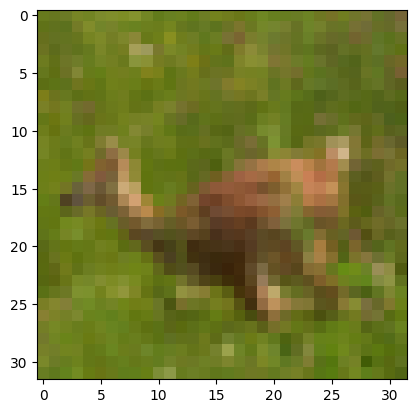

tensor([4])
deer
torch.Size([1, 3, 32, 32])


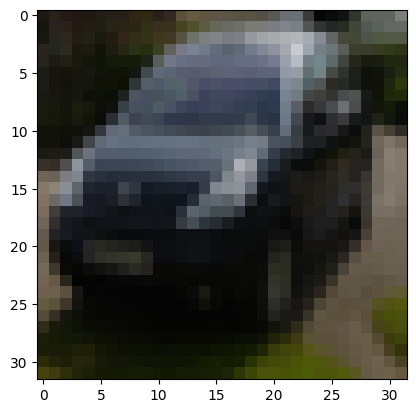

tensor([1])
car
torch.Size([1, 3, 32, 32])


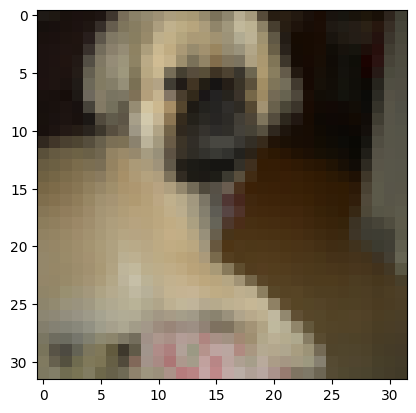

tensor([5])
dog
torch.Size([1, 3, 32, 32])


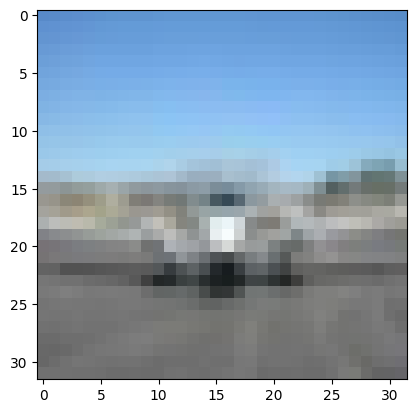

tensor([0])
plane
torch.Size([1, 3, 32, 32])


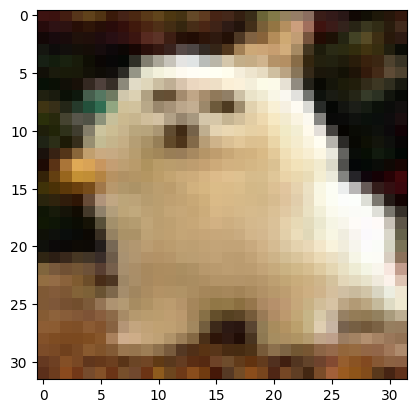

tensor([5])
dog
torch.Size([1, 3, 32, 32])


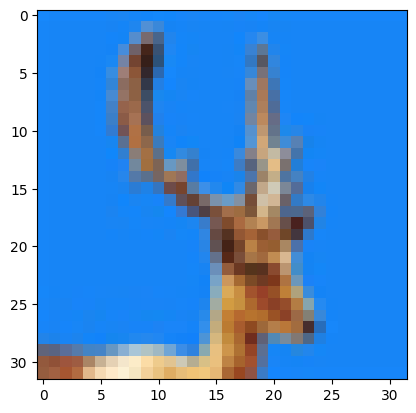

tensor([4])
deer
torch.Size([1, 3, 32, 32])


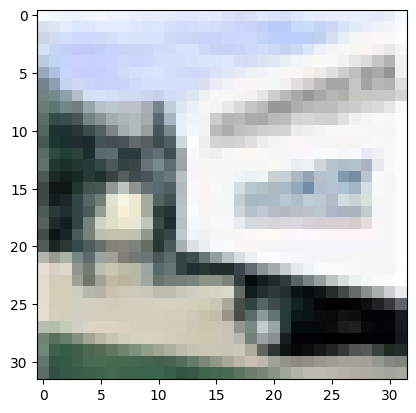

tensor([9])
truck
torch.Size([1, 3, 32, 32])


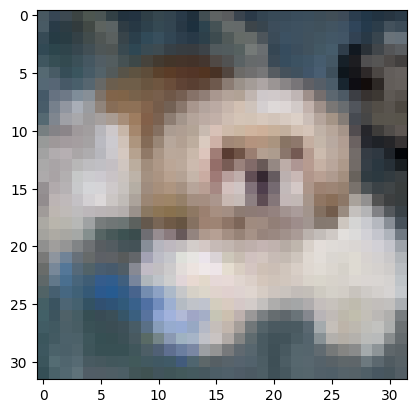

tensor([5])
dog
torch.Size([1, 3, 32, 32])


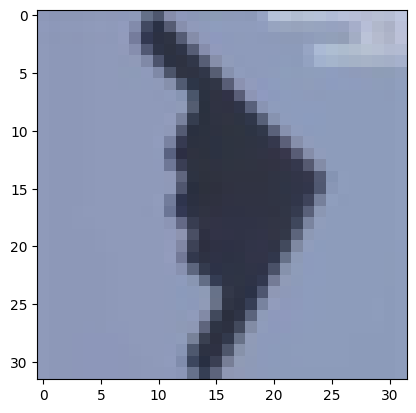

tensor([0])
plane


In [4]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

In [5]:
from torch.nn import ReLU, Softmax, Sequential, Linear, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d

def build_model_task3():
  # We have three channels on input in shape N x 3 x 32 x 32
  model = Sequential(
      Conv2d(3, 32, 3), MaxPool2d(2), ReLU(),
      Conv2d(32, 64, 3), MaxPool2d(2), ReLU(),
      Conv2d(64, 128, 3), MaxPool2d(2), ReLU(),
      AdaptiveAvgPool2d(1),Flatten(),
      Linear(128, 64), ReLU(),
      Linear(64, 32), ReLU(),
      Linear(32, 10))

  model_inference = Sequential(model, Softmax(dim=1))
  return model, model_inference

model, model_inference = build_model_task3()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.1007, 0.1156, 0.0994, 0.0902, 0.1203, 0.0831, 0.0871, 0.1025, 0.0905,
         0.1106]], grad_fn=<SoftmaxBackward0>)
deer


In [6]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

Using device:  cuda:0
Trying optimizer: adam_lr0.01_beta0.85
[{'lr': 0.01, 'betas': (0.85, 0.99), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False, 'params': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}]
Val loss at epoch 0: 1.7704052963074606
Val acc at epoch 0: 0.319
Val loss at epoch 1: 1.623992544830225
Val acc at epoch 1: 0.3788
Val loss at epoch 2: 1.6688051755261268
Val acc at epoch 2: 0.3784
Val loss at epoch 3: 1.5675781137624365
Val acc at epoch 3: 0.4342
Val loss at epoch 4: 1.5117931195125458
Val acc at epoch 4: 0.4454
Val loss at epoch 5: 1.5427043115257457
Val acc at epoch 5: 0.4448
Val loss at epoch 6: 1.478124559305276
Val acc at epoch 6: 0.4712
Val loss at epoch 7: 1.4164551048521783
Val acc at epoch 7: 0.4822
Val loss at epoch 8: 1.4296672294853598
Val acc at epoch 8: 0.4824
Val loss at epoch 9: 1.4295489750090677
Val acc at epoch 9: 0.4752
Val

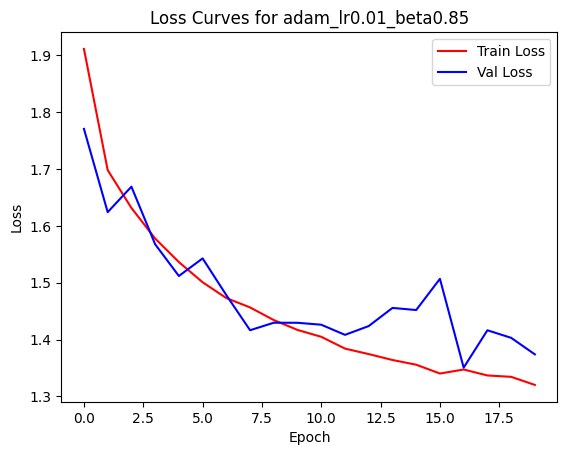

Trying optimizer: adam_lr0.0001
[{'lr': 0.0001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False, 'params': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}]
Val loss at epoch 0: 1.9494941523120661
Val acc at epoch 0: 0.2376
Val loss at epoch 1: 1.8645507355404507
Val acc at epoch 1: 0.2966
Val loss at epoch 2: 1.7510367199114174
Val acc at epoch 2: 0.3402
Val loss at epoch 3: 1.73904936632533
Val acc at epoch 3: 0.3546
Val loss at epoch 4: 1.655116249801247
Val acc at epoch 4: 0.3788
Val loss at epoch 5: 1.6159604400586172
Val acc at epoch 5: 0.3986
Val loss at epoch 6: 1.5936715435829891
Val acc at epoch 6: 0.4156
Val loss at epoch 7: 1.5817616039021
Val acc at epoch 7: 0.415
Val loss at epoch 8: 1.5422038265094635
Val acc at epoch 8: 0.4278
Val loss at epoch 9: 1.519560255062808
Val acc at epoch 9: 0.4396
Val loss at epoch 10: 1.51758150538

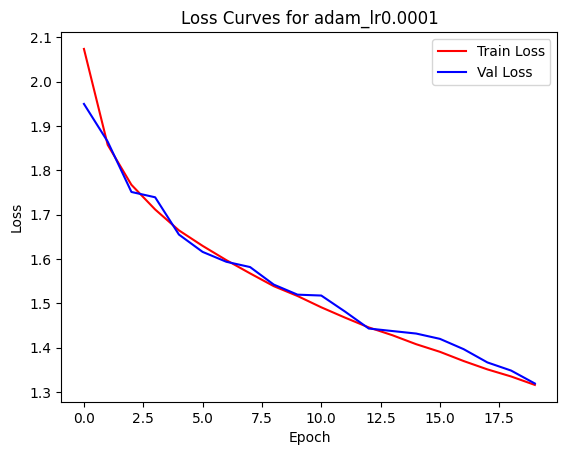

Trying optimizer: SGD_lr0.01
[{'lr': 0.01, 'momentum': 0.9, 'dampening': 0, 'weight_decay': 0, 'nesterov': False, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'params': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}]
Val loss at epoch 0: 1.9770621630796201
Val acc at epoch 0: 0.2406
Val loss at epoch 1: 1.5560504099366013
Val acc at epoch 1: 0.4218
Val loss at epoch 2: 1.2755476331255238
Val acc at epoch 2: 0.5306
Val loss at epoch 3: 1.4159300152663212
Val acc at epoch 3: 0.4978
Val loss at epoch 4: 1.1026448440399899
Val acc at epoch 4: 0.5976
Val loss at epoch 5: 1.2032367127716161
Val acc at epoch 5: 0.5832
Val loss at epoch 6: 1.0082827684985605
Val acc at epoch 6: 0.6486
Val loss at epoch 7: 0.9515140204672601
Val acc at epoch 7: 0.667
Val loss at epoch 8: 0.9589675452299179
Val acc at epoch 8: 0.6768
Val loss at epoch 9: 0.9622408466733945
Val acc at epoch 9: 0.6676
Val loss at epoch 10: 0.9959622222906465
Val acc at epoch 10: 0.6746
Val loss at epoch 11:

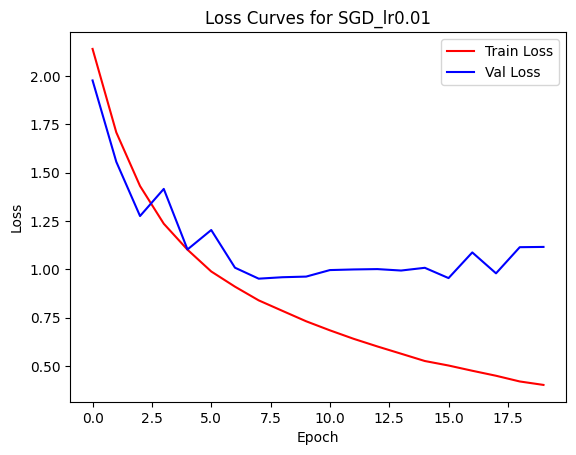

Trying optimizer: SGD_lr0.1
[{'lr': 0.1, 'momentum': 0.9, 'dampening': 0, 'weight_decay': 0, 'nesterov': False, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'params': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}]
Val loss at epoch 0: 2.3084179216129765
Val acc at epoch 0: 0.1024
Val loss at epoch 1: 2.3053720103707285
Val acc at epoch 1: 0.0942
Val loss at epoch 2: 2.3080700111996597
Val acc at epoch 2: 0.0942
Val loss at epoch 3: 2.3168142935272993
Val acc at epoch 3: 0.1028
Val loss at epoch 4: 2.3155531184688494
Val acc at epoch 4: 0.0942
Val loss at epoch 5: 2.3082275041349374
Val acc at epoch 5: 0.1008
Val loss at epoch 6: 2.3099041136966387
Val acc at epoch 6: 0.1
Val loss at epoch 7: 2.306503326270231
Val acc at epoch 7: 0.1064
Val loss at epoch 8: 2.3084418151029356
Val acc at epoch 8: 0.1028
Val loss at epoch 9: 2.3079269904239923
Val acc at epoch 9: 0.1008
Val loss at epoch 10: 2.305328325101524
Val acc at epoch 10: 0.1
Val loss at epoch 11: 2.309590

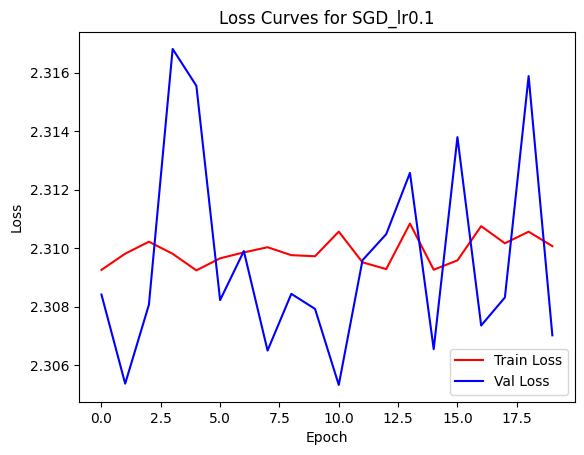

Trying optimizer: RMSprop
[{'lr': 0.01, 'momentum': 0, 'alpha': 0.99, 'eps': 1e-08, 'centered': False, 'weight_decay': 0, 'capturable': False, 'foreach': None, 'maximize': False, 'differentiable': False, 'params': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}]
Val loss at epoch 0: 2.0030558921728923
Val acc at epoch 0: 0.2568
Val loss at epoch 1: 1.90450956183634
Val acc at epoch 1: 0.3104
Val loss at epoch 2: 1.645572562126597
Val acc at epoch 2: 0.3778
Val loss at epoch 3: 1.5892571837279448
Val acc at epoch 3: 0.4336
Val loss at epoch 4: 1.6441321893102805
Val acc at epoch 4: 0.4314
Val loss at epoch 5: 2.6761088652215945
Val acc at epoch 5: 0.2984
Val loss at epoch 6: 1.6643613455401864
Val acc at epoch 6: 0.4306
Val loss at epoch 7: 1.63736074365628
Val acc at epoch 7: 0.4546
Val loss at epoch 8: 1.6853151742819767
Val acc at epoch 8: 0.4398
Val loss at epoch 9: 1.7232159482445686
Val acc at epoch 9: 0.4524
Val loss at epoch 10: 1.5286113179413376
Val acc at epoch 10: 0.4912
Val loss at

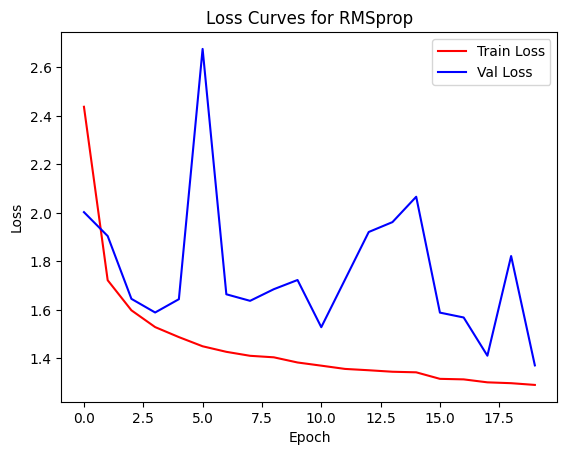

In [ ]:
from torch.optim import Adam, SGD, RMSprop

configs = [ {'name': 'adam_lr0.01_beta0.85','optimizer': lambda: Adam(model.parameters(), lr=0.01, betas=(0.85, 0.99))},
            {'name': 'adam_lr0.0001','optimizer': lambda: Adam(model.parameters(), lr=0.0001)},
            {'name': 'SGD_lr0.01', 'optimizer': lambda: SGD(model.parameters(), lr=0.01, momentum=0.9)},
            {'name': 'SGD_lr0.1', 'optimizer': lambda: SGD(model.parameters(), lr=0.1, momentum=0.9)},
            {'name': 'RMSprop', 'optimizer': lambda: RMSprop(model.parameters())}
          ]

### TODO: dokoncit config setup

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying optimizer: {config['name']}")

    model, model_inference = build_model_task3()
    model.to(device)
    model_inference.to(device)

    optimizer = config['optimizer']()
    print(optimizer.state_dict()['param_groups'])

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(20):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
import json

# Combine the losses and accuracies into a single dictionary
results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

# Specify the filename
output_filename = 'optimizers_results.json'

# Dump the dictionary to a JSON file
with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to optimizers_results.json


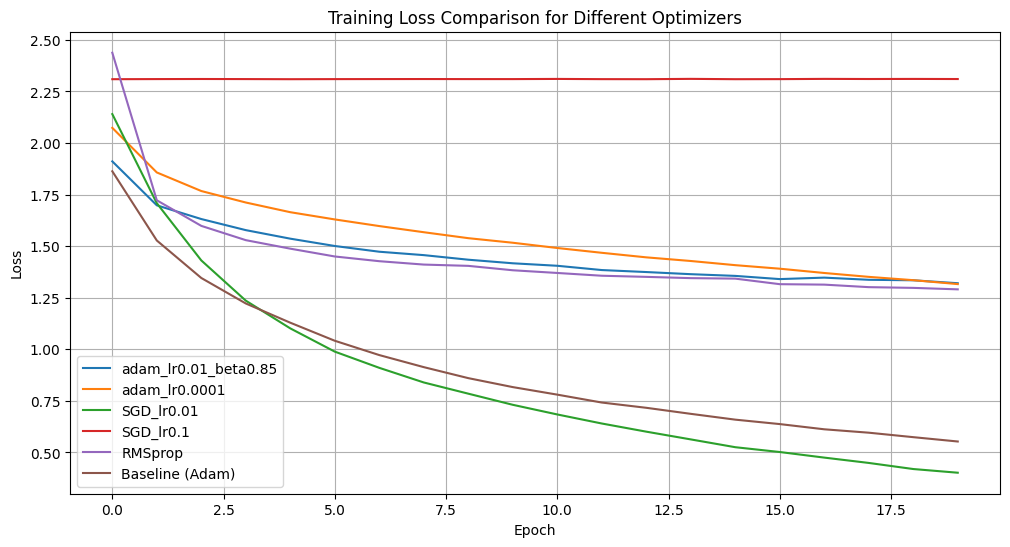

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline (Adam)')

plt.title('Training Loss Comparison for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

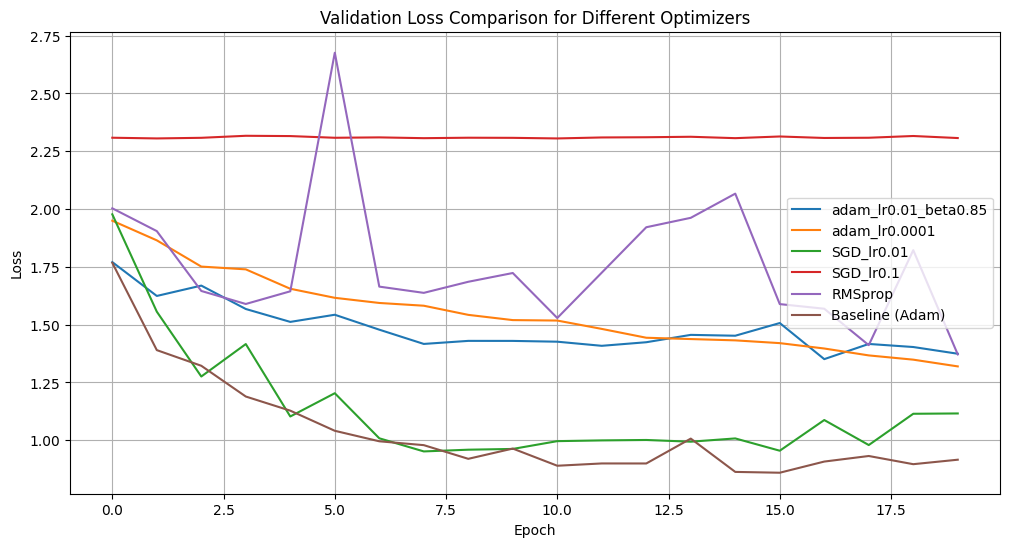

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

# Assuming you have the baseline model's val_losses stored in baseline_val_losses
plt.plot(baseline_val_losses, label='Baseline (Adam)')

plt.title('Validation Loss Comparison for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

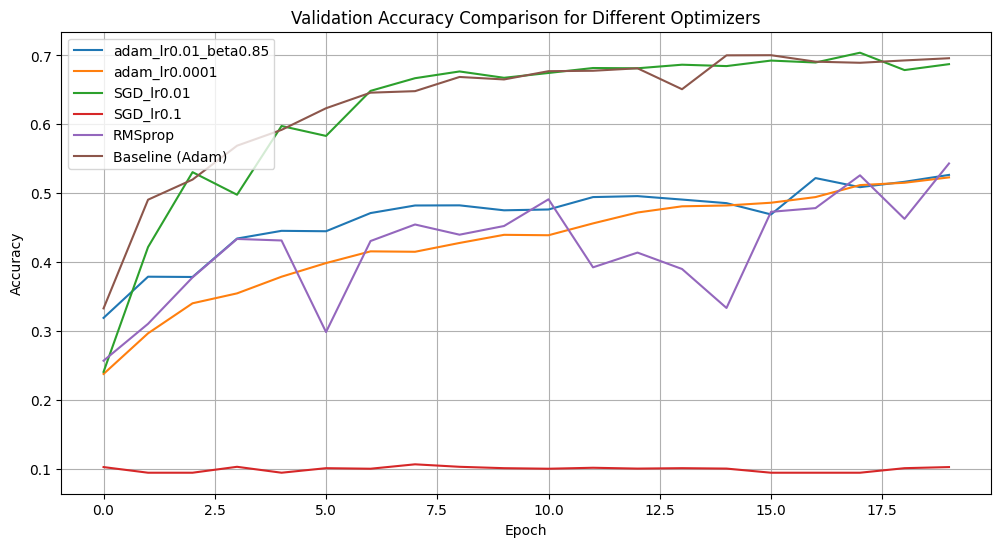

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

# Assuming you have the baseline model's val_accs stored in baseline_val_accs
plt.plot(baseline_val_accs, label='Baseline (Adam)')

plt.title('Validation Accuracy Comparison for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['Baseline (Adam)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (Adam),0.553116,0.915671,0.6960
adam_lr0.01_beta0.85,1.320320,1.374038,0.5266
adam_lr0.0001,1.316099,1.319297,0.5230
SGD_lr0.01,0.401788,1.115736,0.6874
SGD_lr0.1,2.310072,2.307023,0.1024
RMSprop,1.290621,1.371145,0.5432


Using device:  cuda:0
Trying batch size: batch_size_64
Val loss at epoch 0: 1.7707425250282771
Val acc at epoch 0: 0.3334
Val loss at epoch 1: 1.591782150389273
Val acc at epoch 1: 0.4104
Val loss at epoch 2: 1.4597166157975983
Val acc at epoch 2: 0.4568
Val loss at epoch 3: 1.4477677918687653
Val acc at epoch 3: 0.4738
Val loss at epoch 4: 1.3130099486701097
Val acc at epoch 4: 0.5298
Val loss at epoch 5: 1.2289578990091252
Val acc at epoch 5: 0.558
Val loss at epoch 6: 1.1518323617645456
Val acc at epoch 6: 0.5794
Val loss at epoch 7: 1.0987342558329618
Val acc at epoch 7: 0.6066
Val loss at epoch 8: 1.042490701132183
Val acc at epoch 8: 0.6262
Val loss at epoch 9: 1.0313595284389545
Val acc at epoch 9: 0.6222
Val loss at epoch 10: 1.0427311002453672
Val acc at epoch 10: 0.6192
Val loss at epoch 11: 1.074734459194956
Val acc at epoch 11: 0.6194
Val loss at epoch 12: 0.9333680528628675
Val acc at epoch 12: 0.6672
Val loss at epoch 13: 0.9225763746454746
Val acc at epoch 13: 0.6724
Val

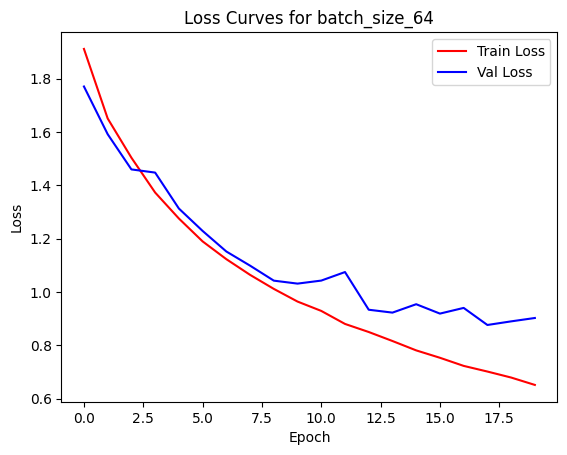

Trying batch size: batch_size_128
Val loss at epoch 0: 1.7967937618494034
Val acc at epoch 0: 0.3246
Val loss at epoch 1: 1.6895926952362061
Val acc at epoch 1: 0.371
Val loss at epoch 2: 1.5744003355503082
Val acc at epoch 2: 0.4324
Val loss at epoch 3: 1.3934257119894027
Val acc at epoch 3: 0.4862
Val loss at epoch 4: 1.3909377813339234
Val acc at epoch 4: 0.4972
Val loss at epoch 5: 1.3069873809814454
Val acc at epoch 5: 0.5264
Val loss at epoch 6: 1.2135627776384355
Val acc at epoch 6: 0.5624
Val loss at epoch 7: 1.2124912351369859
Val acc at epoch 7: 0.5714
Val loss at epoch 8: 1.1941311702132225
Val acc at epoch 8: 0.5748
Val loss at epoch 9: 1.1256700098514556
Val acc at epoch 9: 0.5928
Val loss at epoch 10: 1.0821069911122323
Val acc at epoch 10: 0.6096
Val loss at epoch 11: 1.077019040286541
Val acc at epoch 11: 0.6116
Val loss at epoch 12: 1.0294063821434976
Val acc at epoch 12: 0.6368
Val loss at epoch 13: 1.019510142505169
Val acc at epoch 13: 0.6338
Val loss at epoch 14: 0

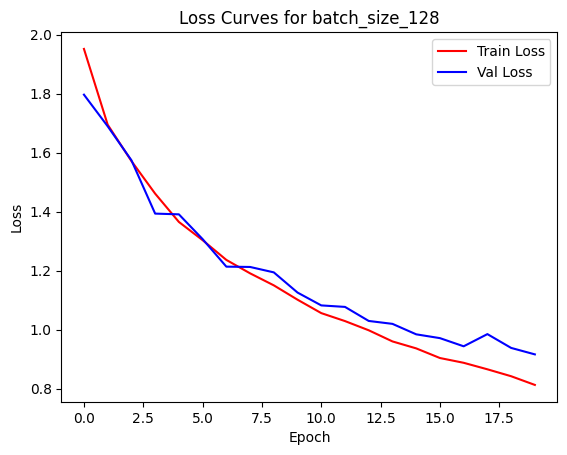

Trying batch size: batch_size_16
Val loss at epoch 0: 1.5219288295069442
Val acc at epoch 0: 0.4308
Val loss at epoch 1: 1.312595939103026
Val acc at epoch 1: 0.5262
Val loss at epoch 2: 1.2103894684261407
Val acc at epoch 2: 0.5602
Val loss at epoch 3: 1.119707761195521
Val acc at epoch 3: 0.6046
Val loss at epoch 4: 1.1546271451936363
Val acc at epoch 4: 0.5896
Val loss at epoch 5: 1.0350580325903602
Val acc at epoch 5: 0.633
Val loss at epoch 6: 0.9976996778489683
Val acc at epoch 6: 0.6444
Val loss at epoch 7: 0.9613437998218658
Val acc at epoch 7: 0.6602
Val loss at epoch 8: 0.918567130121941
Val acc at epoch 8: 0.6766
Val loss at epoch 9: 0.9329287263627251
Val acc at epoch 9: 0.678
Val loss at epoch 10: 0.9392212518868736
Val acc at epoch 10: 0.667
Val loss at epoch 11: 0.9091331842608346
Val acc at epoch 11: 0.6912
Val loss at epoch 12: 0.9059369399810371
Val acc at epoch 12: 0.6912
Val loss at epoch 13: 0.9578088144429575
Val acc at epoch 13: 0.674
Val loss at epoch 14: 0.9442

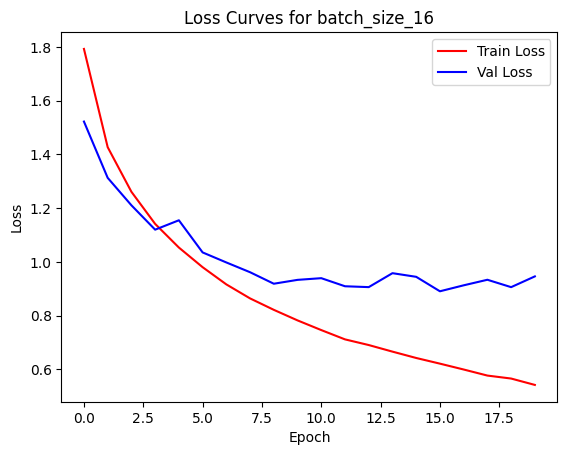

In [7]:
# TODO: Experiments with batch size
from torch.optim import Adam

configs = [ {'name': 'batch_size_64','size': 64},
            {'name': 'batch_size_128','size': 128},
            {'name': 'batch_size_16', 'size': 16}
          ]

### TODO: dokoncit config setup

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying batch size: {config['name']}")

    # Re-initialize model and optimizer for each batch size experiment
    model, model_inference = build_model_task3()
    model.to(device)
    model_inference.to(device)
    optimizer = Adam(model.parameters())


    batch_size = config['size']
    dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(20):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [8]:
import json

# Combine the losses and accuracies into a single dictionary
results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

# Specify the filename
output_filename = 'optimizers_batchsize_results.json'

# Dump the dictionary to a JSON file
with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to optimizers_batchsize_results.json


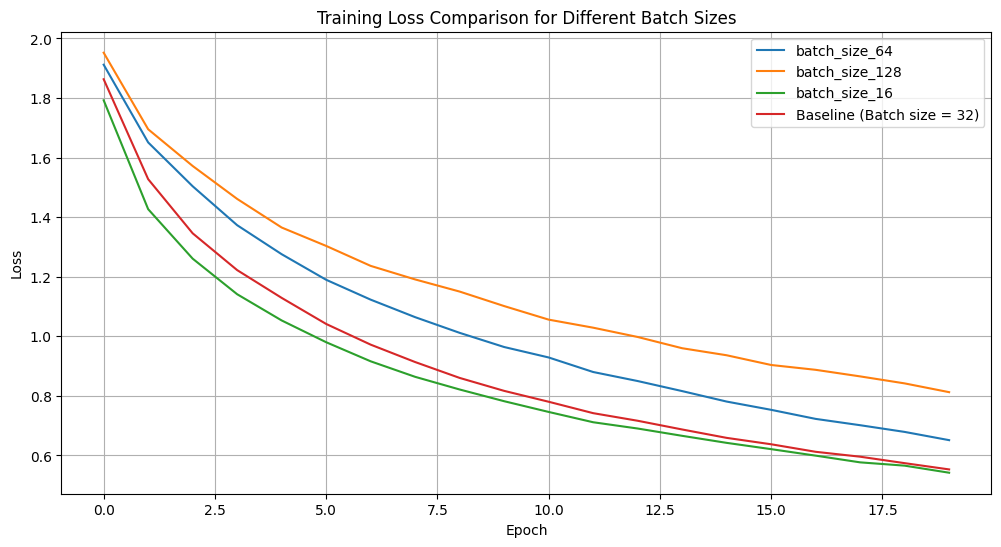

In [9]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(losses[config['name']][0][0], label=config['name'])

plt.plot(baseline_train_losses, label='Baseline (Batch size = 32)')

plt.title('Training Loss Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

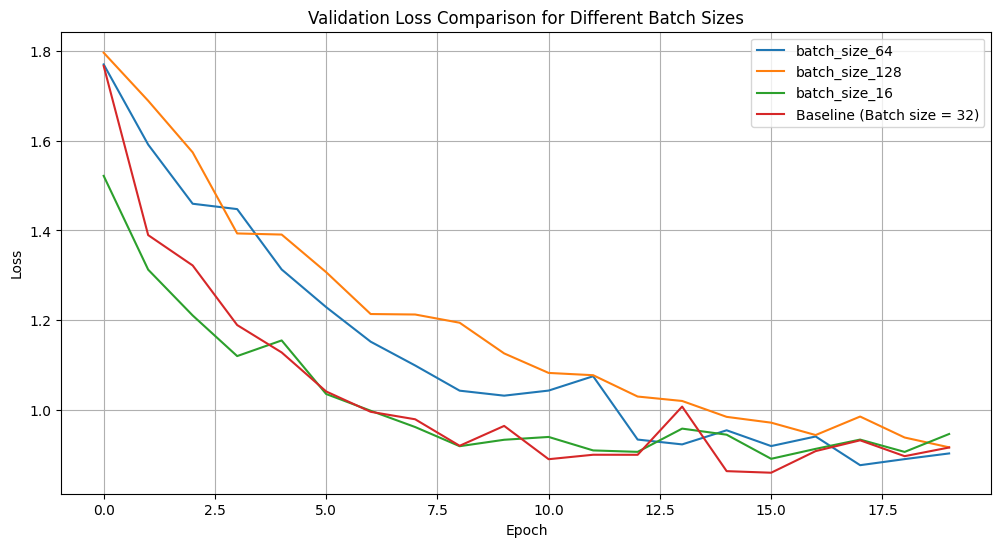

In [10]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(losses[config['name']][1][0], label=config['name'])

# Assuming you have the baseline model's val_losses stored in baseline_val_losses
plt.plot(baseline_val_losses, label='Baseline (Batch size = 32)')

plt.title('Validation Loss Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

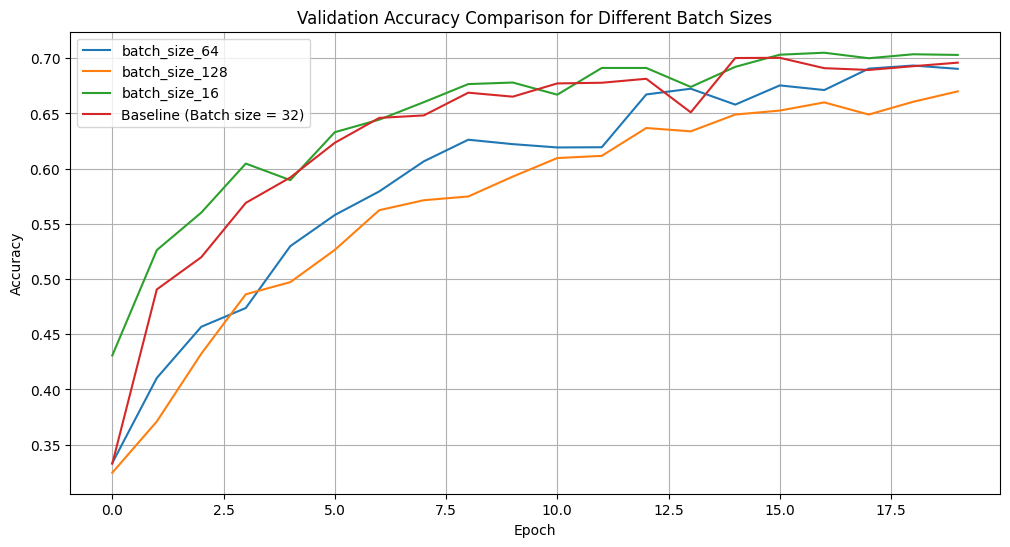

In [11]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(accuracies[config['name']][0], label=config['name'])

# Assuming you have the baseline model's val_accs stored in baseline_val_accs
plt.plot(baseline_val_accs, label='Baseline (Batch size = 32)')

plt.title('Validation Accuracy Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['Baseline (Batch Size = 32)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (Batch Size = 32),0.553116,0.915671,0.6960
batch_size_64,0.651353,0.902417,0.6904
batch_size_128,0.812445,0.916028,0.6700
batch_size_16,0.542035,0.945824,0.7030
